# Lab 3.3 — Time-Series Forecasting: Baselines vs. Transformer
Membandingkan Naive baseline, 1D-CNN, dan Transformer kecil pada deret waktu sintetis (sine + trend + noise).

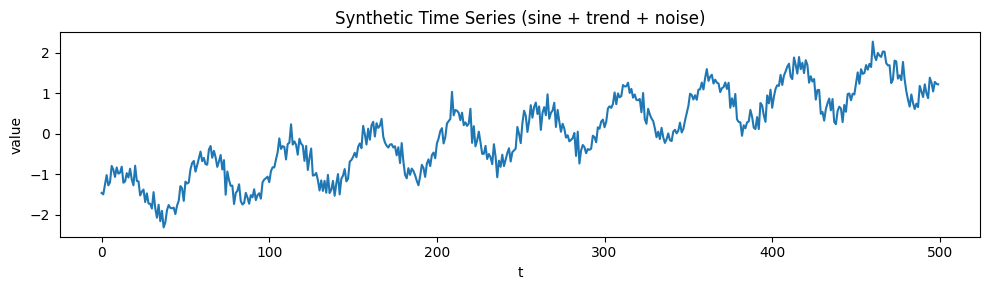

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
T_total = 500
t = np.arange(T_total)
series = np.sin(2 * np.pi * t / 50) + 0.01 * t + np.random.randn(T_total) * 0.3
series = (series - series.mean()) / series.std()

plt.figure(figsize=(10, 3))
plt.plot(series)
plt.title('Synthetic Time Series (sine + trend + noise)')
plt.xlabel('t'); plt.ylabel('value')
plt.tight_layout(); plt.show()

In [2]:
WINDOW = 50
HORIZON = 10

def make_dataset(series, window, horizon):
    X, Y = [], []
    for i in range(len(series) - window - horizon):
        X.append(series[i:i+window])
        Y.append(series[i+window:i+window+horizon])
    X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1)
    Y = torch.tensor(np.array(Y), dtype=torch.float32)
    return X, Y

X, Y = make_dataset(series, WINDOW, HORIZON)
split = int(0.8 * len(X))
X_train, Y_train = X[:split], Y[:split]
X_val, Y_val = X[split:], Y[split:]
print(f'Train: {X_train.shape} | Val: {X_val.shape}')

Train: torch.Size([352, 50, 1]) | Val: torch.Size([88, 50, 1])


## Baseline: Naive forecast

In [3]:
def naive_forecast(X_val, horizon):
    return X_val[:, -1, 0].unsqueeze(1).expand(-1, horizon)

naive_pred = naive_forecast(X_val, HORIZON)
naive_mse = ((naive_pred - Y_val) ** 2).mean().item()
print(f'Naive MSE: {naive_mse:.4f}')

Naive MSE: 0.1925


## Model A: 1D-CNN & Model B: Transformer

In [4]:
class CNN1DForecaster(nn.Module):
    def __init__(self, window=WINDOW, horizon=HORIZON):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(64, horizon)
        )

    def forward(self, x):
        return self.net(x.permute(0, 2, 1))


class TransformerForecaster(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, window=WINDOW, horizon=HORIZON):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_emb = nn.Embedding(window, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        B, W, _ = x.shape
        x = self.input_proj(x)
        pos = torch.arange(W, device=x.device)
        x = x + self.pos_emb(pos).unsqueeze(0)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.head(x)

In [5]:
def train_forecaster(model, X_tr, Y_tr, X_val, Y_val, epochs=50):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    for ep in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        pred = model(X_tr)
        loss = loss_fn(pred, Y_tr)
        loss.backward()
        opt.step()
        if ep % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_val), Y_val).item()
            print(f'Epoch {ep:3d} | Train MSE: {loss.item():.4f} | Val MSE: {val_loss:.4f}')
    model.eval()
    with torch.no_grad():
        return loss_fn(model(X_val), Y_val).item()

cnn_model = CNN1DForecaster()
trans_model = TransformerForecaster()
print('--- Training CNN ---')
cnn_mse = train_forecaster(cnn_model, X_train, Y_train, X_val, Y_val)
print('--- Training Transformer ---')
trans_mse = train_forecaster(trans_model, X_train, Y_train, X_val, Y_val)

print(f'\n=== Final Validation MSE ===')
print(f'Naive: {naive_mse:.4f}')
print(f'1D-CNN: {cnn_mse:.4f}')
print(f'Transformer: {trans_mse:.4f}')

--- Training CNN ---
Epoch  10 | Train MSE: 0.4915 | Val MSE: 1.6807
Epoch  20 | Train MSE: 0.3649 | Val MSE: 1.2606
Epoch  30 | Train MSE: 0.2967 | Val MSE: 0.7135
Epoch  40 | Train MSE: 0.2607 | Val MSE: 0.3458
Epoch  50 | Train MSE: 0.2562 | Val MSE: 0.2736
--- Training Transformer ---
Epoch  10 | Train MSE: 0.1855 | Val MSE: 0.2677
Epoch  20 | Train MSE: 0.1440 | Val MSE: 0.2774
Epoch  30 | Train MSE: 0.1074 | Val MSE: 0.1782
Epoch  40 | Train MSE: 0.0704 | Val MSE: 0.1410
Epoch  50 | Train MSE: 0.0631 | Val MSE: 0.1127

=== Final Validation MSE ===
Naive: 0.1925
1D-CNN: 0.2736
Transformer: 0.1127


## Deliverable 1: bar chart perbandingan

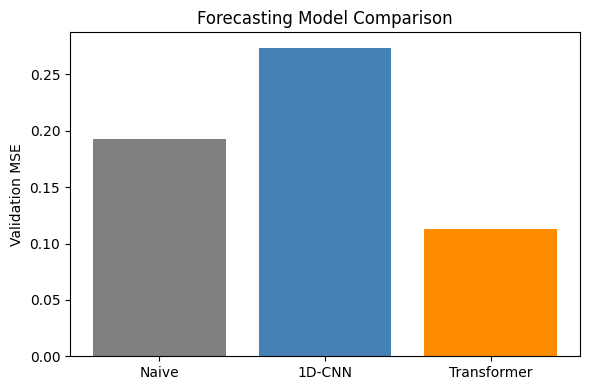

In [6]:
models = ['Naive', '1D-CNN', 'Transformer']
mses = [naive_mse, cnn_mse, trans_mse]
plt.figure(figsize=(6, 4))
plt.bar(models, mses, color=['gray', 'steelblue', 'darkorange'])
plt.ylabel('Validation MSE')
plt.title('Forecasting Model Comparison')
plt.tight_layout(); plt.savefig('lab33_mse_comparison.png', dpi=150); plt.show()

## Deliverable 2: actual vs predicted (model terbaik)

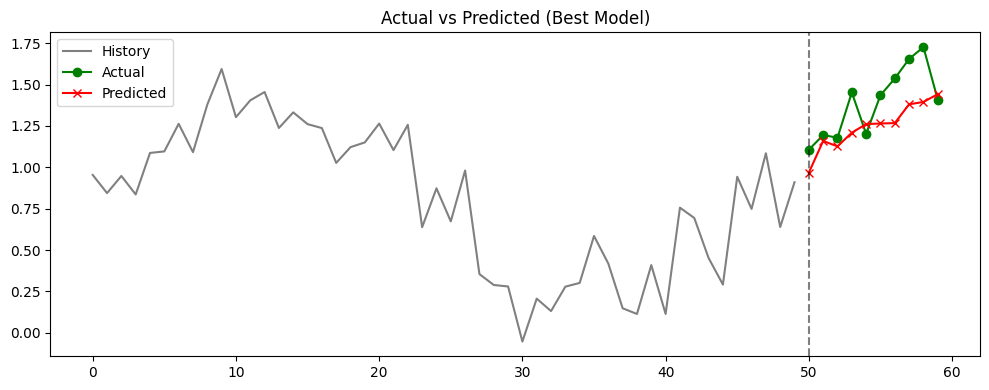

In [7]:
best_model = cnn_model if cnn_mse <= trans_mse else trans_model
best_model.eval()
with torch.no_grad():
    pred = best_model(X_val[:1])

plt.figure(figsize=(10, 4))
history = X_val[0, :, 0].numpy()
actual_future = Y_val[0].numpy()
pred_future = pred[0].numpy()

plt.plot(range(WINDOW), history, label='History', color='gray')
plt.plot(range(WINDOW, WINDOW + HORIZON), actual_future, label='Actual', color='green', marker='o')
plt.plot(range(WINDOW, WINDOW + HORIZON), pred_future, label='Predicted', color='red', marker='x')
plt.axvline(WINDOW, color='black', linestyle='--', alpha=0.5)
plt.legend(); plt.title('Actual vs Predicted (Best Model)')
plt.tight_layout(); plt.savefig('lab33_actual_vs_pred.png', dpi=150); plt.show()